<a href="https://colab.research.google.com/github/anuhingankar9922-hub/-Python-Basic-Projects/blob/main/Optional_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Insurance Dataset

In [57]:
import pandas as pd
df = pd.read_csv("/content/insurance.csv")

print("-----------------------First 5 Rows-----------------------")
print(df.head())
print("\n--Shape--")
print(df.shape)
print("\n---------Dataset Information---------")
print(df.info())

-----------------------First 5 Rows-----------------------
   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86

--Shape--
(1338, 7)

---------Dataset Information---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [58]:
print("-:Missing Values in Column:-")
print(df.isnull().sum())
print("\n->Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

-:Missing Values in Column:-
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

->Duplicate Rows: 1


In [59]:
print("--------------------Statistical Summary--------------------")
print(df.describe())

--------------------Statistical Summary--------------------
               age          bmi     children      expenses
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.665520     1.095737  13279.121638
std      14.044333     6.100664     1.205571  12110.359657
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4746.340000
50%      39.000000    30.400000     1.000000   9386.160000
75%      51.000000    34.700000     2.000000  16657.720000
max      64.000000    53.100000     5.000000  63770.430000


-------------------------------------------------------------Histograms----------------------------------------------------------



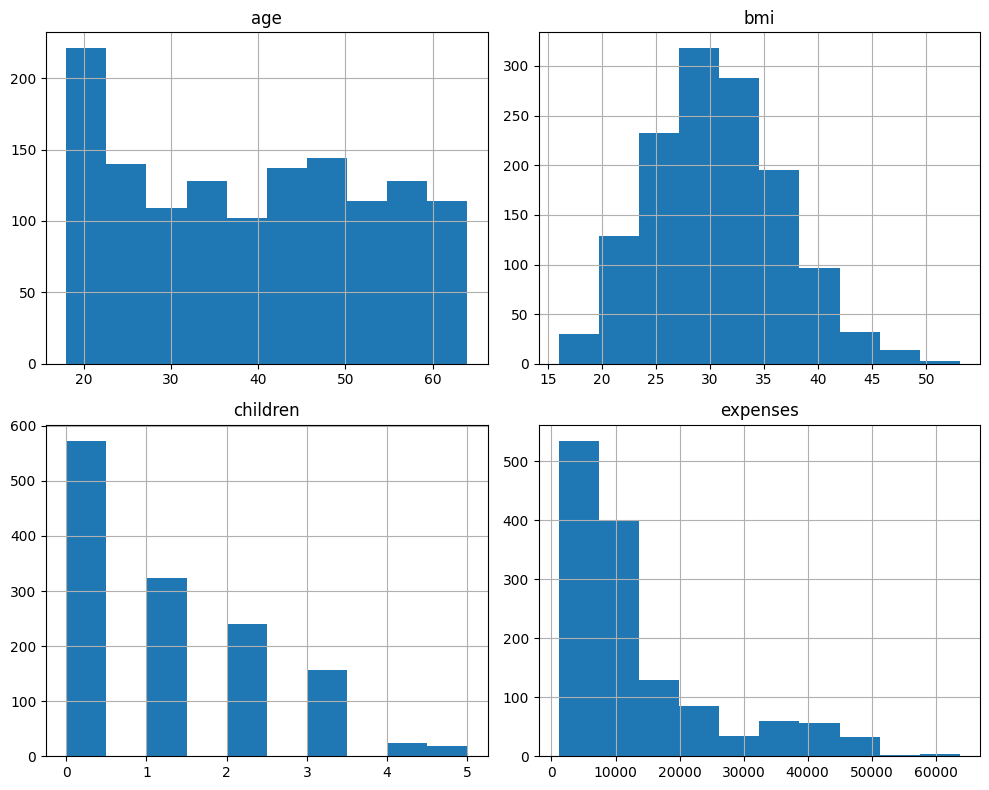

In [60]:
print("-------------------------------------------------------------Histograms----------------------------------------------------------\n")
import matplotlib.pyplot as plt

df[["age","bmi","children","expenses"]].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

------------------------------------------------------------------------Count Plots------------------------------------------------------------------------



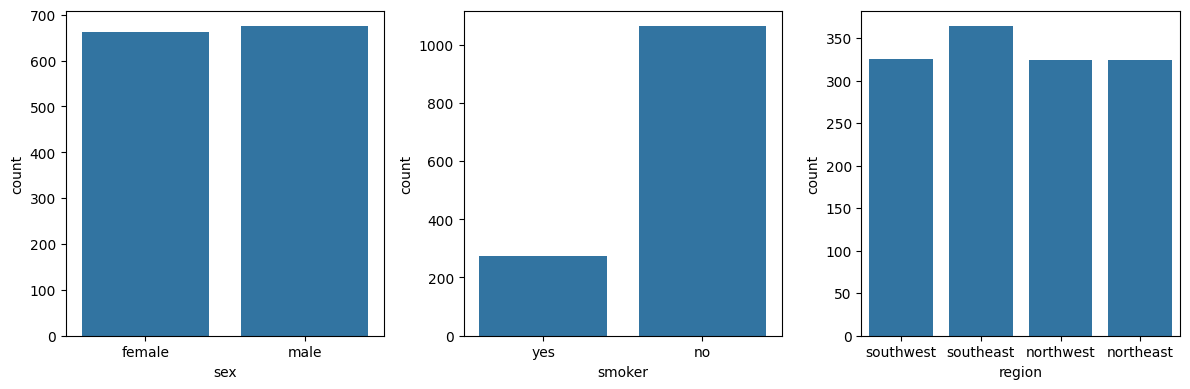

In [61]:
print("------------------------------------------------------------------------Count Plots------------------------------------------------------------------------\n")
import seaborn as sns

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.countplot(x="sex", data=df)

plt.subplot(1,3,2)
sns.countplot(x="smoker", data=df)

plt.subplot(1,3,3)
sns.countplot(x="region", data=df)

plt.tight_layout()
plt.show()

-------------------------------Correlation Heatmap-------------------------------



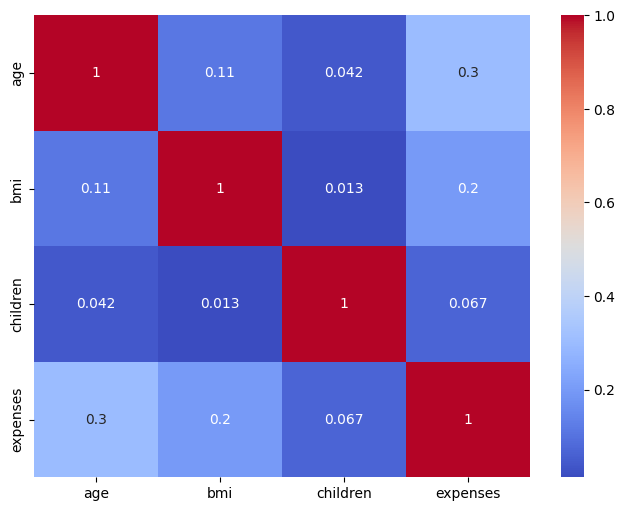

In [62]:
print("-------------------------------Correlation Heatmap-------------------------------\n")
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [63]:
print("-------------------------------Identify Features----------------------------\n")
X = df.drop("expenses", axis=1)
y = df["expenses"]

print(X.columns)
print(y.name)

-------------------------------Identify Features----------------------------

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')
expenses


In [64]:
print("--------------------------------One-Hot Encoding--------------------------------")
df_encoded = pd.get_dummies(df, columns=["sex","smoker","region"])
print(df_encoded.head())

--------------------------------One-Hot Encoding--------------------------------
   age   bmi  children  expenses  sex_female  sex_male  smoker_no  smoker_yes  \
0   19  27.9         0  16884.92        True     False      False        True   
1   18  33.8         1   1725.55       False      True       True       False   
2   28  33.0         3   4449.46       False      True       True       False   
3   33  22.7         0  21984.47       False      True       True       False   
4   32  28.9         0   3866.86       False      True       True       False   

   region_northeast  region_northwest  region_southeast  region_southwest  
0             False             False             False              True  
1             False             False              True             False  
2             False             False              True             False  
3             False              True             False             False  
4             False              True             Fa

In [65]:
print("-------------------------------Feature Scaling-------------------------------")
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("expenses", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())


-------------------------------Feature Scaling-------------------------------
        age       bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
0 -1.440418 -0.453484 -0.909234    1.009771 -1.009771  -1.969660    1.969660   
1 -1.511647  0.513986 -0.079442   -0.990324  0.990324   0.507702   -0.507702   
2 -0.799350  0.382803  1.580143   -0.990324  0.990324   0.507702   -0.507702   
3 -0.443201 -1.306169 -0.909234   -0.990324  0.990324   0.507702   -0.507702   
4 -0.514431 -0.289506 -0.909234   -0.990324  0.990324   0.507702   -0.507702   

   region_northeast  region_northwest  region_southeast  region_southwest  
0         -0.565546         -0.565546         -0.611638          1.764609  
1         -0.565546         -0.565546          1.634955         -0.566698  
2         -0.565546         -0.565546          1.634955         -0.566698  
3         -0.565546          1.768203         -0.611638         -0.566698  
4         -0.565546          1.768203         -0.611638      

16'optional task Dataset (Employee_Performance_Dataset)

In [66]:
import pandas as pd

df = pd.read_csv("/content/Employee_Performance_Dataset.csv")

print("-------------------------Data Loading-------------------------")
print(df.head(10))
print(df.tail())
print("\n---------Shape---------", df.shape)
print("\n------Data Types------")
print(df.dtypes)

-------------------------Data Loading-------------------------
   EmployeeID  Age Department  Experience  Salary  WorkHours  \
0        1001   29      Sales           8   78598         42   
1        1002   30    Finance           8   74348         37   
2        1003   24         IT           3   36140         42   
3        1004   34         IT           5   57493         49   
4        1005   22  Marketing           0   75753         45   
5        1006   31      Sales           7   80036         38   
6        1007   46      Sales          24   53526         43   
7        1008   51  Marketing          22   38180         37   
8        1009   45         HR          15   42601         36   
9        1010   40         IT          18   86054         38   

         Performance  
0               Good  
1  Needs Improvement  
2          Excellent  
3            Average  
4            Average  
5          Excellent  
6          Excellent  
7            Average  
8               Good  
9 

In [67]:
print("---Missing & Duplicate Values---")

print("\n->Missing Values:-")
print(df.isnull().sum())

print("\n->Duplicate Rows:-", df.duplicated().sum())

df = df.drop_duplicates()

---Missing & Duplicate Values---

->Missing Values:-
EmployeeID     0
Age            0
Department     0
Experience     0
Salary         0
WorkHours      0
Performance    0
dtype: int64

->Duplicate Rows:- 0


In [68]:
print("-----------------------Statistical Summary-----------------------\n")
print(df.describe())

-----------------------Statistical Summary-----------------------

       EmployeeID        Age  Experience        Salary  WorkHours
count    50.00000  50.000000   50.000000     50.000000  50.000000
mean   1025.50000  38.280000   13.380000  62464.020000  42.240000
std      14.57738   9.883071    9.824771  17470.468683   4.578388
min    1001.00000  22.000000    0.000000  36140.000000  35.000000
25%    1013.25000  30.000000    5.000000  44796.250000  38.000000
50%    1025.50000  37.000000   11.000000  61060.000000  42.500000
75%    1037.75000  46.750000   21.000000  79112.500000  45.000000
max    1050.00000  54.000000   32.000000  89337.000000  50.000000


---:<>:----------:<>:----------:<>:----------:<>:----:<>:--Histograms--:<>:----:<>:----------:<>:----------:<>:----------:<>:---



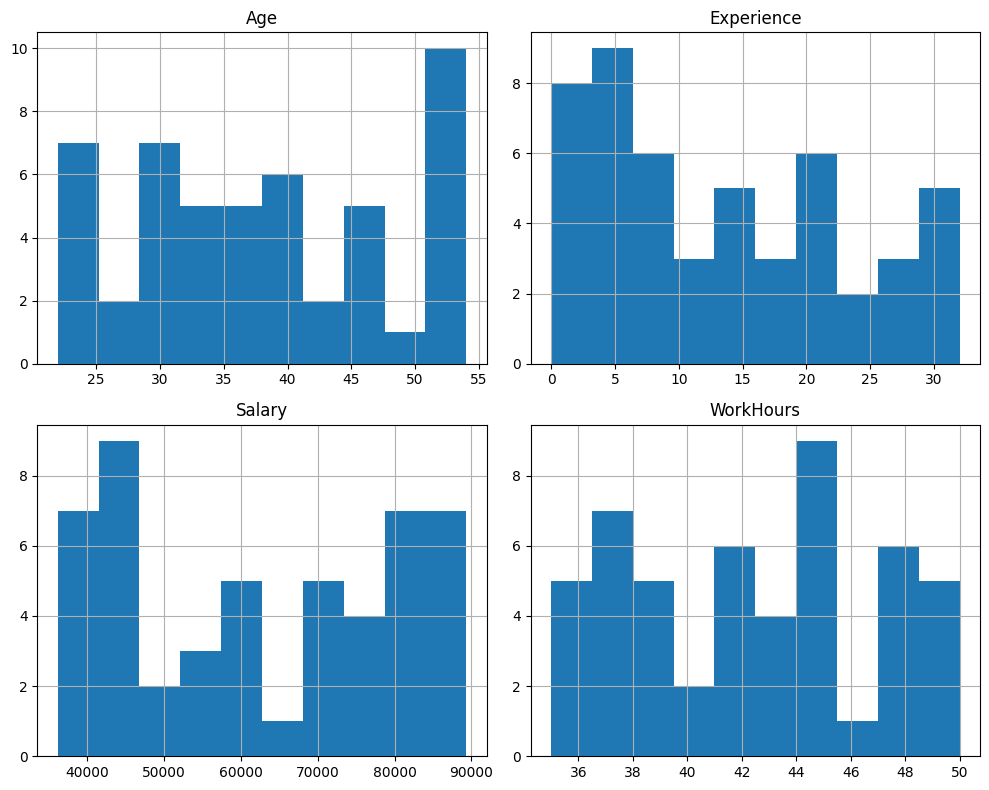

In [69]:
import matplotlib.pyplot as plt

print("---:<>:----------:<>:----------:<>:----------:<>:----:<>:--Histograms--:<>:----:<>:----------:<>:----------:<>:----------:<>:---\n")

df[["Age","Experience","Salary","WorkHours"]].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

-<><><>------<><><>------<><><>------<><><>------<><><>------<><><>-----Count Plots-----<><><>------<><><>------<><><>------<><><>------<><><>------<><><>-



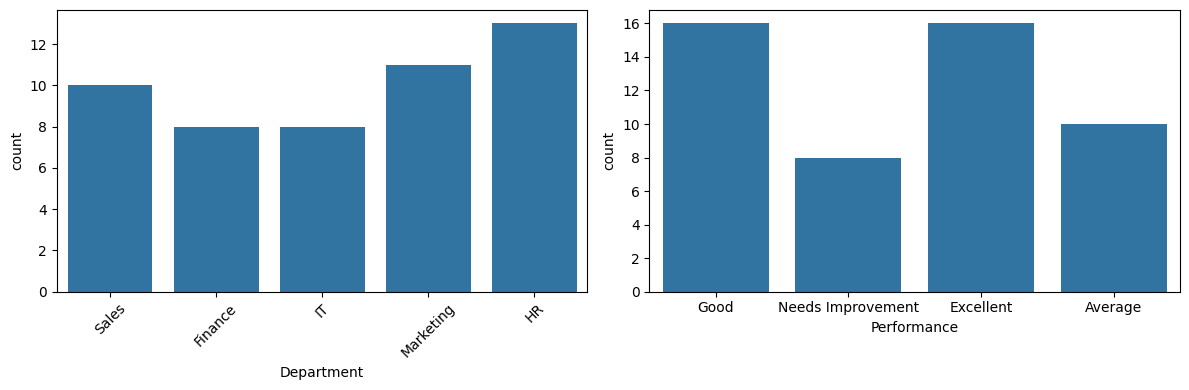

In [70]:
import seaborn as sns

print("-<><><>------<><><>------<><><>------<><><>------<><><>------<><><>-----Count Plots-----<><><>------<><><>------<><><>------<><><>------<><><>------<><><>-\n")

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x="Department", data=df)
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.countplot(x="Performance", data=df)

plt.tight_layout()
plt.show()

:><:---:><:---:><:---:><:---Correlation Heatmap---:><:---:><:---:><:---:><:



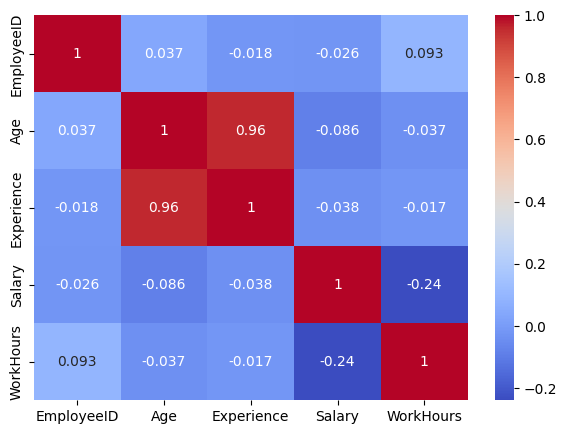

In [71]:
print(":><:---:><:---:><:---:><:---Correlation Heatmap---:><:---:><:---:><:---:><:\n")

plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [72]:
print("---===---===---===---===---===---=>  Feature Identification  <=---===---===---===---===---===---\n")

X = df.drop("Performance", axis=1)
y = df["Performance"]

print("->Independent Features:")
print(X.columns)

print("\n->Dependent Feature:")
print(y.name)

---===---===---===---===---===---=>  Feature Identification  <=---===---===---===---===---===---

->Independent Features:
Index(['EmployeeID', 'Age', 'Department', 'Experience', 'Salary', 'WorkHours'], dtype='object')

->Dependent Feature:
Performance


In [73]:
print("><><><><><><><><><><><><><  One-Hot Encoding  ><><><><><><><><><><><><><\n")

print("------->Before Encoding<-------")
print(df[["Department","Performance"]].head())

df_encoded = pd.get_dummies(df, columns=["Department","Performance"])
print()
print("\n-><><><---<><><>---><><><---After Encoding---><><><---<><><>---><><><-")
print(df_encoded.head())

><><><><><><><><><><><><><  One-Hot Encoding  ><><><><><><><><><><><><><

------->Before Encoding<-------
  Department        Performance
0      Sales               Good
1    Finance  Needs Improvement
2         IT          Excellent
3         IT            Average
4  Marketing            Average


-><><><---<><><>---><><><---After Encoding---><><><---<><><>---><><><-
   EmployeeID  Age  Experience  Salary  WorkHours  Department_Finance  \
0        1001   29           8   78598         42               False   
1        1002   30           8   74348         37                True   
2        1003   24           3   36140         42               False   
3        1004   34           5   57493         49               False   
4        1005   22           0   75753         45               False   

   Department_HR  Department_IT  Department_Marketing  Department_Sales  \
0          False          False                 False              True   
1          False          False         

In [74]:
from sklearn.preprocessing import StandardScaler

print("-(())-----[[]]---(())---Feature Scaling---(())------[[]]------(())-\n")

X = df_encoded.drop(columns=["EmployeeID"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

-(())-----[[]]---(())---Feature Scaling---(())------[[]]------(())-

        Age  Experience    Salary  WorkHours  Department_Finance  \
0 -0.948512   -0.553155  0.932876  -0.052952           -0.436436   
1 -0.846302   -0.553155  0.687139  -1.156127            2.291288   
2 -1.459564   -1.067239 -1.522070  -0.052952           -0.436436   
3 -0.437460   -0.861606 -0.287427   1.491493           -0.436436   
4 -1.663985   -1.375690  0.768376   0.608953           -0.436436   

   Department_HR  Department_IT  Department_Marketing  Department_Sales  \
0      -0.592749      -0.436436             -0.531085               2.0   
1      -0.592749      -0.436436             -0.531085              -0.5   
2      -0.592749       2.291288             -0.531085              -0.5   
3      -0.592749       2.291288             -0.531085              -0.5   
4      -0.592749      -0.436436              1.882938              -0.5   

   Performance_Average  Performance_Excellent  Performance_Good  \
0   

In [75]:
# Summary:
#  The dataset was loaded successfully and explored using Pandas.
#  Missing values and duplicate records were checked and handled.
#  A statistical summary was generated to understand the numerical features.
#  Histograms and count plots were created to visualize the distribution of data.
#  A correlation heatmap was used to identify relationships between numerical features.
#  Independent (input) and dependent (target) features were identified.
#  Categorical columns were converted into numerical format using One-Hot Encoding.
#  Numeric features were standardized using StandardScaler.
#  The dataset is now clean, preprocessed, and ready for machine learning model development.

New Dataset()

In [76]:
from numpy import dtype
import pandas as pd
df=pd.read_csv("/content/archive (3).zip")
print("------------------------->___First 5 Rows___<-------------------------\n")
print(df.head())
print()
print("\n..................>>>__________Last 5 Rows__________<<<.................\n")
print(df.tail())
print()
print("-:Shape:-")
print(df.shape)
print()
print(",,,,,,,,,>>_DataType_<<,,,,,,,,,\n")
print(df.dtypes)

------------------------->___First 5 Rows___<-------------------------

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


..................>>>__________Last 5 Rows__________<<<.................

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137             

In [77]:
print(":-----:Missing & Duplicate Values:-----:")

print("\n-:-:-:-Missing Values-:-:-:-")
print(df.isnull().sum())

print("\n->Duplicate Rows:-", df.duplicated().sum())

df = df.drop_duplicates()

:-----:Missing & Duplicate Values:-----:

-:-:-:-Missing Values-:-:-:-
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

->Duplicate Rows:- 0


In [78]:
print("____________________Information____________________\n")
print(df.info())

____________________Information____________________

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [79]:
print("-------<><><>--------------Statistical Summary--------------<><><>-------\n")
print(df.describe())

-------<><><>--------------Statistical Summary--------------<><><>-------

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


-----<><><>-------<><><>-----<><><>---<><><>---:-:-:-------Histograms-------:-:-:---<><><>---<><><>-----<><><>-------<><><>-----



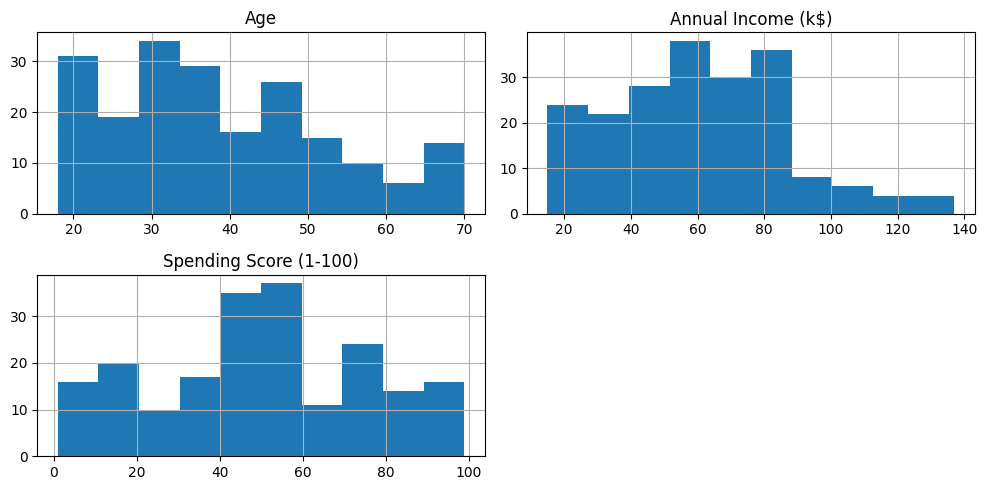

In [80]:
import matplotlib.pyplot as plt

print("-----<><><>-------<><><>-----<><><>---<><><>---:-:-:-------Histograms-------:-:-:---<><><>---<><><>-----<><><>-------<><><>-----\n")

df[["Age","Annual Income (k$)","Spending Score (1-100)"]].hist(figsize=(10,5))

plt.tight_layout()
plt.show()

-<><><>-------<><><>-----Count Plot-----<><><>-------<><><>-



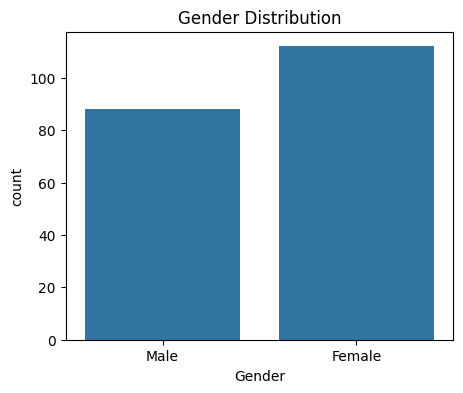

In [81]:
import seaborn as sns

print("-<><><>-------<><><>-----Count Plot-----<><><>-------<><><>-\n")

plt.figure(figsize=(5,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

----<-><-><-><->-<-><-><-><->----Correlation Heatmap----<-><-><-><->-<-><-><-><->----



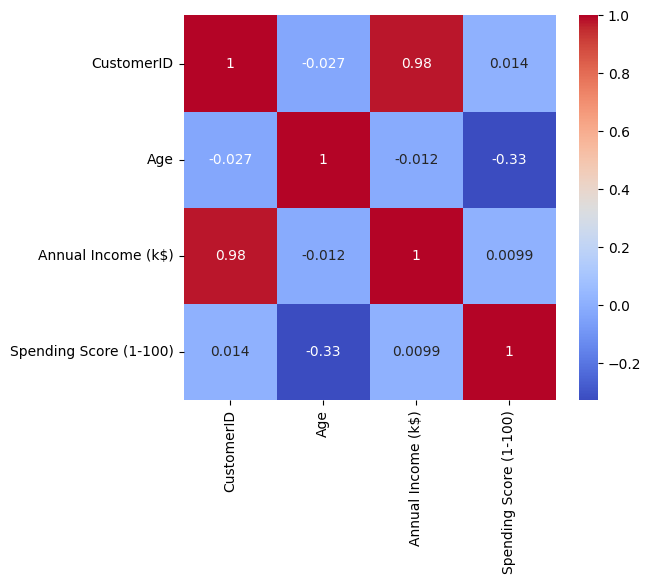

In [82]:
print("----<-><-><-><->-<-><-><-><->----Correlation Heatmap----<-><-><-><->-<-><-><-><->----\n")

plt.figure(figsize=(6,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.show()

In [83]:
print("------(((((())))))---------Feature Identification--------(((((())))))------\n")

X = df.drop("Spending Score (1-100)", axis=1)

y = df["Spending Score (1-100)"]

print("->Independent Features:")
print(X.columns)

print("\n->Dependent Feature:")
print(y.name)

------(((((())))))---------Feature Identification--------(((((())))))------

->Independent Features:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)'], dtype='object')

->Dependent Feature:
Spending Score (1-100)


In [84]:
print("----:-:-:-:-:-:-:-:------------One-Hot Encoding------------:-:-:-:-:-:-:-:----")

print("\n-:Before Encoding:-")

print(df[["Gender"]].head())

df_encoded = pd.get_dummies(df, columns=["Gender"])
print()
print("\n---:-:-:-:-:-:-:-:-:-:-:-:------After Encoding------:-:-:-:-:-:-:-:-:-:-:-:---\n")

print(df_encoded.head())

----:-:-:-:-:-:-:-:------------One-Hot Encoding------------:-:-:-:-:-:-:-:----

-:Before Encoding:-
   Gender
0    Male
1    Male
2  Female
3  Female
4  Female


---:-:-:-:-:-:-:-:-:-:-:-:------After Encoding------:-:-:-:-:-:-:-:-:-:-:-:---

   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Gender_Female  \
0           1   19                  15                      39          False   
1           2   21                  15                      81          False   
2           3   20                  16                       6           True   
3           4   23                  16                      77           True   
4           5   31                  17                      40           True   

   Gender_Male  
0         True  
1         True  
2        False  
3        False  
4        False  


In [85]:
from sklearn.preprocessing import StandardScaler

print("____________________________Feature Scaling____________________________\n")

X = df_encoded.drop("Spending Score (1-100)", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

____________________________Feature Scaling____________________________

   CustomerID       Age  Annual Income (k$)  Gender_Female  Gender_Male
0   -1.723412 -1.424569           -1.738999      -1.128152     1.128152
1   -1.706091 -1.281035           -1.738999      -1.128152     1.128152
2   -1.688771 -1.352802           -1.700830       0.886405    -0.886405
3   -1.671450 -1.137502           -1.700830       0.886405    -0.886405
4   -1.654129 -0.563369           -1.662660       0.886405    -0.886405


In [86]:
# Summary:
#  Loaded the Mall Customers dataset successfully.
#  Checked and handled missing values and duplicate records.
#  Generated the statistical summary using describe().
#  Created histograms to understand the distribution of Age, Annual Income, and Spending Score.
#  Created a count plot for Gender distribution.
#  Used a correlation heatmap to identify relationships among numerical features.
#  Identified independent and dependent features.
#  Applied One-Hot Encoding on the Gender column.
#  Applied StandardScaler to the independent features.
#  The dataset is now preprocessed and ready for machine learning.